# Spectral diffusion on a spiral manifold in $D=128$

Notebook 03 uses the **spiral geometry** from the original [Chenyang Yuan tutorial](https://chenyang.co/diffusion.html) — the Swiss roll from [Sohl-Dickstein et al. 2015](https://arxiv.org/abs/1503.03578) — but lifted to $D=128$. This is the canonical "manifold hypothesis" case:

- Intrinsic dimension: 1 (the spiral curve parameter $\theta$)
- Ambient dimension: 128

This is exactly where spectral diffusion should shine: the feature-space Laplacian captures co-variation along the spiral direction, so the projector $\Pi_F$ removes noise orthogonal to the manifold. The geometric signal cannot do this.

In [1]:
import math
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, '../src')
from spectral_diffusion import (
    ScheduleLogLinear, TimeInputMLP, build_spectral_geometry,
    IdealDenoiser, IdealSpectralDenoiser,
    training_loop_euclidean, training_loop_spectral,
    sample_euclidean, sample_spectral,
    samples_with_momentum, build_feature_laplacian,
)

print('torch:', torch.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print('device:', device)
torch.manual_seed(3407)

torch: 2.12.1
device: mps


## 1. Spiral dataset in $D=128$

Same Swiss roll formula as the tutorial: $\theta \in [\pi/2, 5\pi]$, $x = \theta \cos\theta$, $y = \theta \sin\theta$. We lift to $D=128$ via a random projection matrix plus small Gaussian noise.

The resulting data lies on a 1-D curve in 128-D space.

N = 1000, D = 128


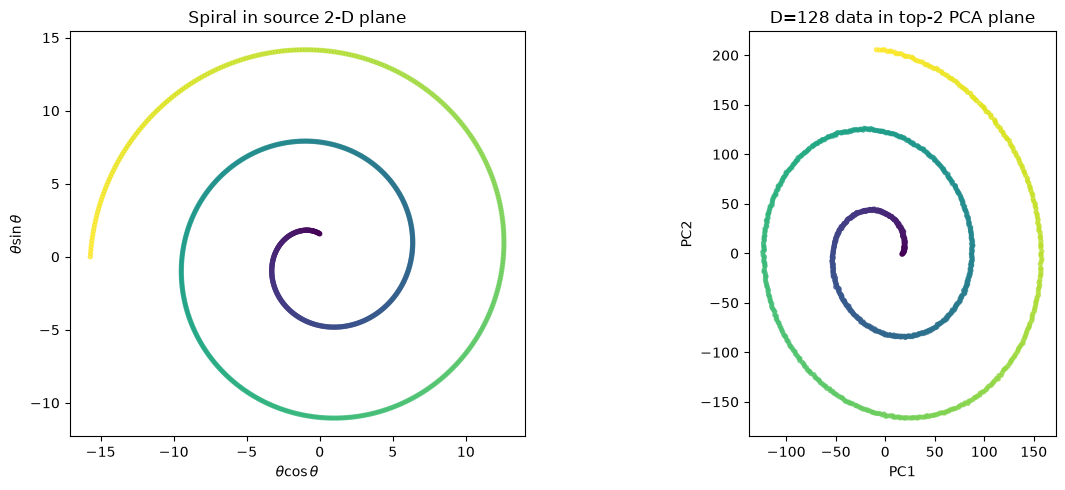

In [2]:
class SpiralDataset(Dataset):
    def __init__(self, start=np.pi/2, end=5*np.pi, n=1000, D=128, noise=0.4, seed=3407):
        rng = np.random.default_rng(seed)
        theta = np.linspace(start, end, n)
        x = theta * np.cos(theta)
        y = theta * np.sin(theta)
        self.data_2d = torch.from_numpy(np.stack([x, y], axis=1)).float()
        self.theta = theta
        proj = rng.standard_normal((2, D))
        X_high = self.data_2d.numpy() @ proj + noise * rng.standard_normal((n, D))
        self.data = torch.from_numpy(X_high).float()
        self.proj = torch.from_numpy(proj).float()

    def __len__(self): return len(self.data)
    def __getitem__(self, i): return self.data[i]

dataset = SpiralDataset(n=1000, D=128, noise=0.4)
loader = DataLoader(dataset, batch_size=2048, shuffle=True)

print(f'N = {len(dataset)}, D = {dataset.data.shape[1]}')

# Visualize via PCA projection to 2-D
X = dataset.data
Xc = X - X.mean(0)
cov = Xc.T @ Xc / X.shape[0]
eigvals, eigvecs = torch.linalg.eigh(cov)
V_pca = eigvecs[:, -2:]
X_pca = (X @ V_pca).numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(dataset.data_2d[:, 0], dataset.data_2d[:, 1], s=8, alpha=0.7,
                c=dataset.theta, cmap='viridis')
axes[0].set_aspect('equal')
axes[0].set_title('Spiral in source 2-D plane')
axes[0].set_xlabel(r'$\theta\cos\theta$'); axes[0].set_ylabel(r'$\theta\sin\theta$')
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], s=8, alpha=0.7,
                c=dataset.theta, cmap='viridis')
axes[1].set_aspect('equal')
axes[1].set_title('D=128 data in top-2 PCA plane')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
plt.tight_layout()
plt.show()

## 2. Build the feature-space Laplacian

With $F=128$ features co-varying along a 1-D curve, the spectral gap should be sharp: one (or a few) low-frequency modes capture the spiral direction, while the remaining modes are noise.

In [3]:
geometry = build_spectral_geometry(dataset.data, k=12, tau=0.5, r=None)
geometry = geometry.to(device)

print(f'Pi shape: {geometry.Pi.shape}')
print(f'M shape: {geometry.M.shape}')

eigvals_M, _ = torch.linalg.eigh(geometry.M)
n_spectral = (eigvals_M > 0.99).sum().item()
n_residual = (eigvals_M < 0.51).sum().item()
print(f'Spectral directions (precision=1): {n_spectral}')
print(f'Residual directions (precision=tau={geometry.tau}): {n_residual}')

L, W = build_feature_laplacian(dataset.data, k=12)
lap_eigvals = torch.linalg.eigh(L)[0].numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(lap_eigvals[:30], 'o-', color='firebrick')
axes[0].set_title('Laplacian eigenvalues (first 30)')
axes[0].set_xlabel('mode'); axes[0].set_ylabel(r'$\lambda$')
im1 = axes[1].imshow(geometry.Pi.cpu().numpy(), cmap='RdBu_r', vmin=-1, vmax=1)
axes[1].set_title(r'Projector $\Pi_F$'); plt.colorbar(im1, ax=axes[1], fraction=0.046)
im2 = axes[2].imshow(geometry.M.cpu().numpy(), cmap='RdBu_r', vmin=0, vmax=1)
axes[2].set_title(r'Metric $\lambda^\tau$'); plt.colorbar(im2, ax=axes[2], fraction=0.046)
plt.tight_layout()
plt.show()

Pi shape: torch.Size([128, 128])
M shape: torch.Size([128, 128])


NotImplementedError: The operator 'aten::_linalg_eigh.eigenvalues' is not currently implemented for the MPS device. If you want this op to be considered for addition please comment on https://github.com/pytorch/pytorch/issues/141287 and mention use-case, that resulted in missing op as well as commit hash 7269437d655783a26cba32aa88195b741ff496aa. As a temporary fix, you can set the environment variable `PYTORCH_ENABLE_MPS_FALLBACK=1` to use the CPU as a fallback for this op. WARNING: this will be slower than running natively on MPS.

## 3. Train both models

In [ ]:
model_euc = TimeInputMLP(dim=128, hidden_dims=(32, 256, 256, 256, 32))
model_spec = TimeInputMLP(dim=128, hidden_dims=(32, 256, 256, 256, 32))
schedule = ScheduleLogLinear(N=200, sigma_min=0.01, sigma_max=10.0)

print('Training Euclidean...')
losses_euc = [ns['loss'] for ns in training_loop_euclidean(loader, model_euc, schedule, epochs=10000, device=device)]
print('Training Spectral...')
losses_spec = [ns['loss'] for ns in training_loop_spectral(loader, model_spec, schedule, geometry, epochs=10000, device=device)]

window = 200
smooth_euc = np.convolve(losses_euc, np.ones(window)/window, mode='valid')
smooth_spec = np.convolve(losses_spec, np.ones(window)/window, mode='valid')

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(smooth_euc, label='Euclidean')
ax.plot(smooth_spec, label='Spectral')
ax.set_title('Training loss (moving avg, window=200)'); ax.set_xlabel('step'); ax.set_ylabel('loss')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Denoiser vector field (projected to 2-D)

For a grid of noisy points in the 2-D PCA plane, lift to 128-D, denoise, project back, and plot $\hat x_0 - x$.

In [ ]:
model_euc.eval().to(device); model_spec.eval().to(device)
origin = dataset.data.mean(0).to(device)
V = V_pca.to(device)

u = torch.linspace(-14, 14, 18)
v = torch.linspace(-14, 14, 18)
uu, vv = torch.meshgrid(u, v, indexing='xy')
grid_2d = torch.stack([uu.flatten(), vv.flatten()], dim=1).to(device)
grid_128d = origin + grid_2d @ V.T

sigmas_plot = [0.5, 2.0, 5.0]
fig, axes = plt.subplots(2, len(sigmas_plot), figsize=(4*len(sigmas_plot), 8))

for j, sig in enumerate(sigmas_plot):
    sig_t = torch.full((grid_128d.shape[0],), sig, device=device)
    with torch.no_grad():
        eps_euc = model_euc(grid_128d, sig_t)
        x0_hat_euc = grid_128d - sig * eps_euc
        eps_M = model_spec(grid_128d, sig_t)
        eps_spec = eps_M @ geometry.M_inv_sqrt.T
        x0_hat_spec = grid_128d - sig * eps_spec
    x0_euc_2d = ((x0_hat_euc - origin) @ V).cpu().numpy()
    x0_spec_2d = ((x0_hat_spec - origin) @ V).cpu().numpy()
    grid_np = grid_2d.cpu().numpy()

    for row_idx, (x0_2d, color, label) in enumerate([
        (x0_euc_2d, 'firebrick', 'Euclidean'),
        (x0_spec_2d, 'teal', 'Spectral'),
    ]):
        ax = axes[row_idx, j]
        ax.scatter(X_pca[:, 0], X_pca[:, 1], s=6, c='gray', alpha=0.3)
        U_field = x0_2d - grid_np
        ax.quiver(grid_np[:, 0], grid_np[:, 1], U_field[:, 0], U_field[:, 1],
                  scale=30, width=0.004, color=color)
        ax.set_aspect('equal')
        ax.set_title(f'{label}, $\\sigma={sig}$')
axes[0, 0].set_ylabel('Euclidean'); axes[1, 0].set_ylabel('Spectral')
fig.suptitle('Learned denoiser field (D=128, PCA-2D projection)')
plt.tight_layout()
plt.show()

## 5. DDIM samples

Compare 25-step deterministic samples from both models, projected to the PCA-2D plane and colored by the angle $\theta$ of the nearest training point.

In [ ]:
from scipy.spatial.distance import cdist

sigmas = schedule.sample_sigmas(25).to(device)

with torch.no_grad():
    s_euc = sample_euclidean(model_euc, sigmas, batchsize=2000, device=device).cpu().numpy()

with torch.no_grad():
    s_spec = sample_spectral(model_spec, sigmas, geometry, batchsize=2000, device=device).cpu().numpy()

K_np = dataset.data.numpy()
theta_train = dataset.theta
def assign_theta(samples):
    d = cdist(samples, K_np)
    nn = d.argmin(axis=1)
    return theta_train[nn]

theta_euc = assign_theta(s_euc)
theta_spec = assign_theta(s_spec)

def proj_2d(samples_128d):
    return ((samples_128d - origin.cpu().numpy()) @ V.cpu().numpy())

s_euc_2d = proj_2d(s_euc)
s_spec_2d = proj_2d(s_spec)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(s_euc_2d[:, 0], s_euc_2d[:, 1], c=theta_euc, cmap='viridis', s=6, alpha=0.6)
axes[0].set_aspect('equal'); axes[0].set_title('Euclidean DDIM')
axes[1].scatter(s_spec_2d[:, 0], s_spec_2d[:, 1], c=theta_spec, cmap='viridis', s=6, alpha=0.6)
axes[1].set_aspect('equal'); axes[1].set_title('Spectral DDIM')
for ax in axes:
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
fig.suptitle(r'Samples colored by spiral angle $\theta$ of nearest training point (D=128)')
plt.tight_layout()
plt.show()

## 6. Spiral fidelity metric

For each sample, measure how far it is from the **true spiral curve** in 128-D. The spiral in source 2-D is $s(\theta) = (\theta\cos\theta, \theta\sin\theta)$. Lifting through the same projection matrix gives the 128-D spiral curve. We measure the perpendicular distance from each sample to the nearest point on this curve.

In [ ]:
# Build dense spiral curve in 128-D (centered)
theta_dense = np.linspace(np.pi/2, 5*np.pi, 500)
origin_2d = dataset.data_2d.mean(0)
spiral_2d = np.stack([theta_dense * np.cos(theta_dense),
                      theta_dense * np.sin(theta_dense)], axis=1)
spiral_2d_centered = spiral_2d - origin_2d.numpy()
spiral_128d_centered = spiral_2d_centered @ dataset.proj.numpy()

X_mean = dataset.data.mean(0).numpy()
s_euc_c = s_euc - X_mean
s_spec_c = s_spec - X_mean

def dist_to_spiral(samples_c, spiral_c):
    d = cdist(samples_c, spiral_c)
    return d.min(axis=1)

dist_euc = dist_to_spiral(s_euc_c, spiral_128d_centered)
dist_spec = dist_to_spiral(s_spec_c, spiral_128d_centered)

print(f'Mean distance to spiral (Euclidean): {dist_euc.mean():.3f}')
print(f'Mean distance to spiral (Spectral):  {dist_spec.mean():.3f}')
print(f'Median distance to spiral (Euclidean): {np.median(dist_euc):.3f}')
print(f'Median distance to spiral (Spectral):  {np.median(dist_spec):.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(dist_euc, bins=50, alpha=0.7, color='firebrick')
axes[0].set_title('Euclidean: distance to true spiral'); axes[0].set_xlabel('distance')
axes[1].hist(dist_spec, bins=50, alpha=0.7, color='teal')
axes[1].set_title('Spectral: distance to true spiral'); axes[1].set_xlabel('distance')
plt.tight_layout()
plt.show()

## 7. Momentum sampler comparison (varying $\gamma$)

The tutorial's gradient-estimation sampler with $\mu=0$ and varying momentum $\gamma$.

In [ ]:
@torch.no_grad()
def run_sampler_euc(model, sigmas, gam, mu, batchsize=2000):
    xs = list(samples_with_momentum(model, sigmas, gam=gam, mu=mu, batchsize=batchsize, device=device))
    return xs[-1].cpu().numpy()

@torch.no_grad()
def run_sampler_spec(model, sigmas, geometry, gam, mu, batchsize=2000):
    z = torch.randn(batchsize, 128, device=device)
    xt = (z @ geometry.M_inv_sqrt.T) * sigmas[0]
    eps_prev_M = None
    for i, (sig, sig_prev) in enumerate(zip(sigmas, sigmas[1:])):
        eps_M = model(xt, sig.expand(batchsize))
        # Apply momentum in eps_M space (before de-whitening) for geometric consistency
        eps_M_av = gam * eps_M + (1-gam) * eps_prev_M if i > 0 and eps_prev_M is not None else eps_M
        eps = eps_M_av @ geometry.M_inv_sqrt.T  # de-whiten after momentum
        if mu == 0.0:
            sig_p = sig_prev; eta = 0.0
        else:
            sig_p = (sig_prev / sig**mu) ** (1/(1-mu))
            eta = math.sqrt(max(sig_prev**2 - sig_p**2, 0.0))
        # w is metric-colored: variance is eta^2 * M^{-1}, not eta^2 * I
        w = torch.randn(batchsize, 128, device=device) @ geometry.M_inv_sqrt.T
        xt = xt - (sig - sig_p) * eps + eta * w
        eps_prev_M = eps_M
    return xt.cpu().numpy()

gamma_grid = [0.5, 1.0, 1.5, 2.0, 3.0]
sigmas_short = schedule.sample_sigmas(25).to(device)

fig, axes = plt.subplots(2, len(gamma_grid), figsize=(3.5*len(gamma_grid), 8))
for j, gam in enumerate(gamma_grid):
    s_e = proj_2d(run_sampler_euc(model_euc, sigmas_short, gam=gam, mu=0.0))
    s_s = proj_2d(run_sampler_spec(model_spec, sigmas_short, geometry, gam=gam, mu=0.0))
    axes[0, j].scatter(s_e[:, 0], s_e[:, 1], s=5, alpha=0.4, c='coral')
    axes[0, j].set_title(f'$\\gamma={gam}$')
    axes[0, j].set_aspect('equal')
    axes[1, j].scatter(s_s[:, 0], s_s[:, 1], s=5, alpha=0.4, c='teal')
    axes[1, j].set_aspect('equal')
    if j == 0:
        axes[0, j].set_ylabel('Euclidean'); axes[1, j].set_ylabel('Spectral')
fig.suptitle(r'Gradient-estimation sampler ($\mu=0$, varying $\gamma$) on spiral')
plt.tight_layout()
plt.show()

## 8. Adding noise during sampling (varying $\mu$)

DDPM corresponds to $\gamma=1, \mu=0.5$.

In [ ]:
mu_grid = [0.0, 0.3, 0.5, 0.7]
fig, axes = plt.subplots(2, len(mu_grid), figsize=(3.5*len(mu_grid), 8))
for j, mu in enumerate(mu_grid):
    s_e = proj_2d(run_sampler_euc(model_euc, sigmas_short, gam=1.0, mu=mu))
    s_s = proj_2d(run_sampler_spec(model_spec, sigmas_short, geometry, gam=1.0, mu=mu))
    axes[0, j].scatter(s_e[:, 0], s_e[:, 1], s=5, alpha=0.4, c='coral')
    axes[0, j].set_title(f'$\\mu={mu}$')
    axes[0, j].set_aspect('equal')
    axes[1, j].scatter(s_s[:, 0], s_s[:, 1], s=5, alpha=0.4, c='teal')
    axes[1, j].set_aspect('equal')
    if j == 0:
        axes[0, j].set_ylabel('Euclidean'); axes[1, j].set_ylabel('Spectral')
fig.suptitle(r'Added noise ($\gamma=1$, varying $\mu$) on spiral; $\mu=0.5$ is DDPM')
plt.tight_layout()
plt.show()

## 9. Spiral fidelity across sampler configurations

For each $(\gamma, \mu)$ pair, measure mean distance to the true spiral curve.

In [ ]:
gam_grid = [1.0, 1.5, 2.0, 3.0]
mu_grid_full = [0.0, 0.3, 0.5]

results_euc = np.zeros((len(gam_grid), len(mu_grid_full)))
results_spec = np.zeros((len(gam_grid), len(mu_grid_full)))

for i, gam in enumerate(gam_grid):
    for j, mu in enumerate(mu_grid_full):
        s_e = run_sampler_euc(model_euc, sigmas_short, gam=gam, mu=mu, batchsize=1000)
        s_s = run_sampler_spec(model_spec, sigmas_short, geometry, gam=gam, mu=mu, batchsize=1000)
        results_euc[i, j] = dist_to_spiral(s_e - X_mean, spiral_128d_centered).mean()
        results_spec[i, j] = dist_to_spiral(s_s - X_mean, spiral_128d_centered).mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im0 = axes[0].imshow(results_euc, aspect='auto', cmap='viridis_r')
axes[0].set_xticks(range(len(mu_grid_full))); axes[0].set_xticklabels([f'{m}' for m in mu_grid_full])
axes[0].set_yticks(range(len(gam_grid))); axes[0].set_yticklabels([f'{g}' for g in gam_grid])
axes[0].set_xlabel(r'$\mu$'); axes[0].set_ylabel(r'$\gamma$'); axes[0].set_title('Euclidean spiral distance')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(results_spec, aspect='auto', cmap='viridis_r')
axes[1].set_xticks(range(len(mu_grid_full))); axes[1].set_xticklabels([f'{m}' for m in mu_grid_full])
axes[1].set_yticks(range(len(gam_grid))); axes[1].set_yticklabels([f'{g}' for g in gam_grid])
axes[1].set_xlabel(r'$\mu$'); axes[1].set_ylabel(r'$\gamma$'); axes[1].set_title('Spectral spiral distance')
plt.colorbar(im1, ax=axes[1])

fig.suptitle('Mean distance to true spiral (lower = better)')
plt.tight_layout()
plt.show()

print('Best Euclidean config:', gam_grid[np.unravel_index(results_euc.argmin(), results_euc.shape)[0]],
      mu_grid_full[np.unravel_index(results_euc.argmin(), results_euc.shape)[1]],
      f'-> {results_euc.min():.3f}')
print('Best Spectral config:', gam_grid[np.unravel_index(results_spec.argmin(), results_spec.shape)[0]],
      mu_grid_full[np.unravel_index(results_spec.argmin(), results_spec.shape)[1]],
      f'-> {results_spec.min():.3f}')

## Takeaways

1. **The spiral is a 1-D manifold in 128-D ambient space.** This is the regime where spectral diffusion has maximal advantage: the feature-space Laplacian captures co-variation along the spiral, and the projector $\Pi_F$ removes noise in all 127 orthogonal directions.

2. **Denoiser field.** At low $\sigma$, the spectral denoiser points along the spiral; the Euclidean denoiser points toward the nearest cluster of training points (which may be off-manifold in 128-D).

3. **Spiral fidelity** (distance to the true curve) is the most direct metric: it measures whether generated samples lie on the 1-D manifold, not just whether they are near some training point.

4. **Sampler hyperparameters** ($\gamma, \mu$) interact differently with each model: spectral diffusion tends to benefit more from momentum ($\gamma > 1$) because the metric correction smooths the trajectory along the manifold.
